In [1]:
from pathlib import Path

INPUT_BASE = Path('/kaggle/input/datasets')

print("=== Directory tree of your input datasets ===\n")
for dataset_path in INPUT_BASE.iterdir():
    if dataset_path.is_dir():
        print(f"📁 {dataset_path.name}")
        # Show first-level contents
        for sub in dataset_path.iterdir():
            if sub.is_dir():
                print(f"  └── {sub.name}/")
                # Show second-level if exists
                for sub2 in sub.iterdir():
                    if sub2.is_dir():
                        print(f"      └── {sub2.name}/")
                    else:
                        print(f"      └── {sub2.name}")
            else:
                print(f"  └── {sub.name}")
        print()

=== Directory tree of your input datasets ===

📁 shinjinidey
  └── synapse-dataset/
      └── label/
      └── img/

📁 balraj98
  └── cvcclinicdb/
      └── class_dict.csv
      └── metadata.csv
      └── TIF/
      └── PNG/

📁 anhkiettruong
  └── isic18-segmentation-data/
      └── train_valid_tets_list.csv
      └── valid/
      └── test/
      └── train/

📁 anacondaece
  └── isic17/
      └── ISIC_2017_32x32 - Copy/

📁 athina123
  └── ph2dataset/
      └── ph2_dataset/
      └── trainy/
      └── trainx/



In [2]:
# ============================================================
# FINAL PREPROCESSING SCRIPT – All datasets, with corrected Synapse
# ============================================================
import os
import shutil
import random
import re
import numpy as np
import cv2
from pathlib import Path

# Install nibabel if needed
try:
    import nibabel as nib
except ImportError:
    !pip install -q nibabel
    import nibabel as nib

# Configuration
SEED = 42
IMG_SIZE = 256
random.seed(SEED)

OUT_ROOT = Path('/kaggle/working/processed_datasets')
OUT_ROOT.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Helper functions (used by all datasets)
# ------------------------------------------------------------
def resize_image(img):
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)

def resize_mask(mask):
    return cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

def copy_resize_pairs(pairs, out_dir, binary_mask=True):
    """Save a list of (img_path, msk_path) pairs into out_dir/images and out_dir/masks."""
    out_dir = Path(out_dir)
    img_out = out_dir / 'images'
    msk_out = out_dir / 'masks'
    img_out.mkdir(parents=True, exist_ok=True)
    msk_out.mkdir(parents=True, exist_ok=True)
    for img_path, msk_path in pairs:
        # Image
        img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = resize_image(img)
        # Mask
        mask = cv2.imread(str(msk_path), cv2.IMREAD_UNCHANGED)
        if mask is None:
            continue
        if len(mask.shape) == 3:
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
        if binary_mask:
            mask = (mask > 127).astype(np.uint8) * 255
        else:
            mask = mask.astype(np.uint8)
        mask = resize_mask(mask)
        # Save
        base = img_path.stem
        cv2.imwrite(str(img_out / f"{base}.png"), img)
        cv2.imwrite(str(msk_out / f"{base}.png"), mask)

def split_and_save_pairs(pairs, out_dir, binary_mask=True, split_ratios=(0.8,0.1,0.1)):
    """Split pairs into train/val/test and save."""
    out_dir = Path(out_dir)
    random.shuffle(pairs)
    n = len(pairs)
    train_end = int(split_ratios[0] * n)
    val_end = train_end + int(split_ratios[1] * n)
    splits = {
        'train': pairs[:train_end],
        'val':   pairs[train_end:val_end],
        'test':  pairs[val_end:],
    }
    for split_name, items in splits.items():
        if not items:
            continue
        copy_resize_pairs(items, out_dir / split_name, binary_mask)

# ------------------------------------------------------------
# ISIC2018 – already split, just copy
# ------------------------------------------------------------
def process_isic2018():
    src = Path('/kaggle/input/datasets/anhkiettruong/isic18-segmentation-data')
    dst = OUT_ROOT / 'isic2018'
    if dst.exists():
        shutil.rmtree(dst)
    for split in ['train', 'test', 'valid']:
        split_dir = src / split / split   # e.g., train/train
        if not split_dir.is_dir():
            print(f"ISIC2018: {split} split not found at {split_dir}")
            continue
        img_dir = split_dir / 'images'
        msk_dir = split_dir / 'masks'
        if not (img_dir.is_dir() and msk_dir.is_dir()):
            print(f"ISIC2018: {split} missing images/masks at {img_dir} or {msk_dir}")
            continue
        img_files = sorted([f for f in img_dir.glob('*') if f.suffix.lower() in ('.png', '.jpg', '.jpeg')])
        msk_dict = {f.stem: f for f in msk_dir.glob('*') if f.suffix.lower() in ('.png', '.jpg', '.jpeg')}
        pairs = []
        for img in img_files:
            if img.stem in msk_dict:
                pairs.append((img, msk_dict[img.stem]))
        print(f"ISIC2018 {split}: found {len(pairs)} pairs")
        if not pairs:
            continue
        out_split = dst / split
        copy_resize_pairs(pairs, out_split, binary_mask=True)
    if (dst / 'valid').exists():
        (dst / 'valid').rename(dst / 'val')
    print("ISIC2018 done.")

# ------------------------------------------------------------
# ISIC2017 – create splits ourselves
# ------------------------------------------------------------
def process_isic2017():
    src = Path('/kaggle/input/datasets/anacondaece/isic17/ISIC_2017_32x32 - Copy')
    dst = OUT_ROOT / 'isic2017'
    if dst.exists():
        shutil.rmtree(dst)
    train_img_dir = src / 'trainx'
    train_msk_dir = src / 'trainy'
    if not (train_img_dir.is_dir() and train_msk_dir.is_dir()):
        print("ISIC2017: trainx/trainy not found")
        return
    def extract_number(fname):
        m = re.search(r'(\d+)', fname.stem)
        return int(m.group(1)) if m else None
    img_files = [f for f in train_img_dir.glob('*') if f.suffix.lower() in ('.png', '.jpg')]
    msk_files = [f for f in train_msk_dir.glob('*') if f.suffix.lower() in ('.png', '.jpg')]
    img_dict = {extract_number(f): f for f in img_files if extract_number(f) is not None}
    msk_dict = {extract_number(f): f for f in msk_files if extract_number(f) is not None}
    common = set(img_dict.keys()) & set(msk_dict.keys())
    pairs = [(img_dict[num], msk_dict[num]) for num in common]
    print(f"ISIC2017: found {len(pairs)} training pairs")
    if not pairs:
        print("ISIC2017: no training pairs")
        return
    split_and_save_pairs(pairs, dst, binary_mask=True)
    # Test data if exists
    test_img_dir = src / 'testx'
    test_msk_dir = src / 'testy'
    if test_img_dir.is_dir() and test_msk_dir.is_dir():
        test_img_files = [f for f in test_img_dir.glob('*') if f.suffix.lower() in ('.png', '.jpg')]
        test_msk_files = [f for f in test_msk_dir.glob('*') if f.suffix.lower() in ('.png', '.jpg')]
        test_img_dict = {extract_number(f): f for f in test_img_files if extract_number(f) is not None}
        test_msk_dict = {extract_number(f): f for f in test_msk_files if extract_number(f) is not None}
        test_common = set(test_img_dict.keys()) & set(test_msk_dict.keys())
        test_pairs = [(test_img_dict[num], test_msk_dict[num]) for num in test_common]
        print(f"ISIC2017: found {len(test_pairs)} test pairs")
        if test_pairs:
            copy_resize_pairs(test_pairs, dst / 'test', binary_mask=True)
    print("ISIC2017 done.")

# ------------------------------------------------------------
# PH2 – images: IMDxxx.bmp, masks: IMDxxx_lesion.bmp
# ------------------------------------------------------------
def process_ph2():
    src = Path('/kaggle/input/datasets/athina123/ph2dataset')
    dst = OUT_ROOT / 'ph2'
    if dst.exists():
        shutil.rmtree(dst)
    data_dir = src / 'ph2_dataset'
    if not data_dir.is_dir():
        print("PH2: ph2_dataset not found")
        return
    img_dir = data_dir / 'trainx'
    msk_dir = data_dir / 'trainy'
    if not (img_dir.is_dir() and msk_dir.is_dir()):
        print("PH2: trainx/trainy not found")
        return
    img_files = sorted([f for f in img_dir.glob('*') if f.suffix.lower() in ('.bmp', '.png', '.jpg')])
    msk_dict = {}
    for f in msk_dir.glob('*'):
        if f.suffix.lower() in ('.bmp', '.png', '.jpg'):
            stem = f.stem
            if stem.endswith('_lesion'):
                stem = stem[:-7]
            msk_dict[stem] = f
    pairs = [(img, msk_dict[img.stem]) for img in img_files if img.stem in msk_dict]
    print(f"PH2: found {len(pairs)} pairs")
    if not pairs:
        print("PH2: no pairs")
        return
    split_and_save_pairs(pairs, dst, binary_mask=True)
    print("PH2 done.")

# ------------------------------------------------------------
# CVC-ClinicDB – images: PNG/Original, masks: PNG/Ground Truth
# ------------------------------------------------------------
def process_clinicdb():
    src = Path('/kaggle/input/datasets/balraj98/cvcclinicdb')
    dst = OUT_ROOT / 'clinicdb'
    if dst.exists():
        shutil.rmtree(dst)
    img_dir = src / 'PNG' / 'Original'
    msk_dir = src / 'PNG' / 'Ground Truth'
    if not (img_dir.is_dir() and msk_dir.is_dir()):
        print("CVC-ClinicDB: PNG/Original or PNG/Ground Truth not found")
        return
    img_files = sorted([f for f in img_dir.glob('*') if f.suffix.lower() in ('.png', '.jpg', '.tif')])
    msk_dict = {f.stem: f for f in msk_dir.glob('*') if f.suffix.lower() in ('.png', '.jpg', '.tif')}
    pairs = [(img, msk_dict[img.stem]) for img in img_files if img.stem in msk_dict]
    print(f"CVC-ClinicDB: found {len(pairs)} pairs")
    if not pairs:
        print("CVC-ClinicDB: no pairs")
        return
    split_and_save_pairs(pairs, dst, binary_mask=True)
    print("CVC-ClinicDB done.")

# ------------------------------------------------------------
# Synapse – NIfTI volumes to 2D slices (corrected)
# ------------------------------------------------------------
# Tuneable constants for CT windowing
HU_MIN = -125   # standard abdominal CT window: -125 to 275 HU
HU_MAX = 275

def _window_ct(img_data: np.ndarray) -> np.ndarray:
    """Clip CT volume to abdominal HU window and scale to uint8."""
    img = img_data.astype(np.float32)
    img = np.clip(img, HU_MIN, HU_MAX)
    img = (img - HU_MIN) / (HU_MAX - HU_MIN) * 255.0
    return img.astype(np.uint8)

def _save_slice(img_slice_gray, msk_slice_raw, out_dir, filename):
    """Resize and save one axial slice pair. Returns True if mask had non-zero labels."""
    if msk_slice_raw.max() == 0:
        return False
    img_rs = cv2.resize(img_slice_gray, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    img_3ch = cv2.cvtColor(img_rs, cv2.COLOR_GRAY2BGR)
    msk_rs = cv2.resize(msk_slice_raw, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    cv2.imwrite(str(out_dir / 'images' / filename), img_3ch)
    cv2.imwrite(str(out_dir / 'masks' / filename), msk_rs)
    return True

def process_synapse():
    src = Path('/kaggle/input/datasets/shinjinidey/synapse-dataset')
    dst = OUT_ROOT / 'synapse'
    if dst.exists():
        shutil.rmtree(dst)
    img_dir = src / 'img'
    msk_dir = src / 'label'
    if not (img_dir.is_dir() and msk_dir.is_dir()):
        print("Synapse: img/ or label/ not found")
        return
    # List NIfTI files
    img_files = sorted(list(img_dir.glob('*.nii')) + list(img_dir.glob('*.nii.gz')))
    if not img_files:
        print("Synapse: no NIfTI images")
        return
    def extract_num(p):
        m = re.search(r'\d+', p.stem)
        return int(m.group()) if m else None
    img_dict = {extract_num(f): f for f in img_files if extract_num(f) is not None}
    msk_dict = {}
    for f in msk_dir.glob('*'):
        if f.suffix in ('.nii', '.nii.gz'):
            num = extract_num(f)
            if num is not None:
                msk_dict[num] = f
    common = sorted(set(img_dict.keys()) & set(msk_dict.keys()))
    if not common:
        print("Synapse: no matching image/mask pairs")
        return
    paired = [(img_dict[num], msk_dict[num]) for num in common]
    print(f"Synapse: found {len(paired)} patient pairs")
    # Patient split: first 18 train, next 12 test
    n = len(paired)
    n_train_patients = 18
    n_test_patients = 12
    if n < n_train_patients + n_test_patients:
        n_train_patients = n // 2
        n_test_patients = n - n_train_patients
    train_patients = paired[:n_train_patients]
    test_patients = paired[n_train_patients:n_train_patients + n_test_patients]
    # Further split training into train/val (90/10)
    random.shuffle(train_patients)
    n_train = int(0.9 * len(train_patients))
    train_train = train_patients[:n_train]
    train_val = train_patients[n_train:]
    # Create output folders
    for split in ['train', 'val', 'test']:
        (dst / split / 'images').mkdir(parents=True, exist_ok=True)
        (dst / split / 'masks').mkdir(parents=True, exist_ok=True)
    slice_counter = {'train': 0, 'val': 0, 'test': 0}
    def save_slices(img_path, msk_path, split_name):
        img_nii = nib.load(img_path)
        img_data = img_nii.get_fdata().astype(np.float32)
        msk_nii = nib.load(msk_path)
        msk_data = msk_nii.get_fdata().astype(np.uint8)
        if img_data.shape != msk_data.shape:
            print(f"Shape mismatch for {img_path.name}, skipping")
            return
        # Apply CT window to the whole volume
        img_win = _window_ct(img_data)   # uint8, same shape
        # Slice axis: Synapse volumes are (H, W, D) – slice on axis 2
        d = img_data.shape[2]
        for i in range(d):
            img_slice = img_win[:, :, i]
            msk_slice = msk_data[:, :, i]
            filename = f"{img_path.stem}_s{slice_counter[split_name]:06d}.png"
            if _save_slice(img_slice, msk_slice, dst / split_name, filename):
                slice_counter[split_name] += 1
    # Process each split
    for img, msk in train_train:
        save_slices(img, msk, 'train')
    for img, msk in train_val:
        save_slices(img, msk, 'val')
    for img, msk in test_patients:
        save_slices(img, msk, 'test')
    print(f"Synapse done. Slices: train={slice_counter['train']}, val={slice_counter['val']}, test={slice_counter['test']}")

# ------------------------------------------------------------
# Run all
# ------------------------------------------------------------
if __name__ == "__main__":
    print("Starting preprocessing...")
    process_isic2018()
    process_isic2017()
    process_ph2()
    process_clinicdb()
    process_synapse()
    print("\nAll datasets processed. Output saved to", OUT_ROOT)

Starting preprocessing...
ISIC2018 train: found 2585 pairs
ISIC2018 test: found 555 pairs
ISIC2018 valid: found 554 pairs
ISIC2018 done.
ISIC2017: found 2000 training pairs
ISIC2017: found 600 test pairs
ISIC2017 done.
PH2: found 200 pairs
PH2 done.
CVC-ClinicDB: found 612 pairs
CVC-ClinicDB done.
Synapse: found 30 patient pairs
Synapse done. Slices: train=1206, val=132, test=840

All datasets processed. Output saved to /kaggle/working/processed_datasets


In [ ]:
!zip -r processed_datasets.zip /kaggle/working/processed_datasets

In [4]:
# ============================================================
# VERIFICATION: Check all processed datasets
# ============================================================
import cv2
import numpy as np
from pathlib import Path

PROCESSED_ROOT = Path('/kaggle/working/processed_datasets')

def check_dataset(dataset_name, expected_classes, binary_mask=True):
    """Check a processed dataset for structure and mask values."""
    dataset_path = PROCESSED_ROOT / dataset_name
    if not dataset_path.exists():
        print(f"❌ {dataset_name}: directory not found")
        return

    print(f"\n📁 {dataset_name}")
    total_images = 0
    total_masks = 0
    for split in ['train', 'val', 'test']:
        split_path = dataset_path / split
        if not split_path.exists():
            continue
        img_dir = split_path / 'images'
        msk_dir = split_path / 'masks'
        if not img_dir.is_dir() or not msk_dir.is_dir():
            print(f"  ⚠️  {split}: missing images/ or masks/")
            continue
        imgs = list(img_dir.glob('*.png'))
        msks = list(msk_dir.glob('*.png'))
        print(f"  {split}: {len(imgs)} images, {len(msks)} masks")
        total_images += len(imgs)
        total_masks += len(msks)

        # Sample a few masks to verify label values
        if msks and split == 'train':  # only sample from training set
            sample_masks = msks[:5]  # first 5
            print(f"    Sample mask values (first 5 masks):")
            for m in sample_masks:
                mask = cv2.imread(str(m), cv2.IMREAD_UNCHANGED)
                if mask is None:
                    print(f"      {m.name}: failed to read")
                    continue
                unique = np.unique(mask)
                if binary_mask:
                    if set(unique).issubset({0, 255}):
                        print(f"      {m.name}: binary OK (values {unique})")
                    else:
                        print(f"      {m.name}: ❌ not binary (values {unique})")
                else:
                    # multi‑class: expected values 0..expected_classes-1
                    if np.max(unique) < expected_classes and np.min(unique) >= 0:
                        print(f"      {m.name}: multi‑class OK (values {unique[:8]})")
                    else:
                        print(f"      {m.name}: ❌ unexpected values {unique}")

    if total_images != total_masks:
        print(f"  ⚠️  Total images ({total_images}) ≠ total masks ({total_masks})")
    else:
        print(f"  ✅ Total {total_images} image/mask pairs")

# Datasets specifications
datasets = {
    'isic2018': {'expected_classes': 1, 'binary_mask': True},
    'isic2017': {'expected_classes': 1, 'binary_mask': True},
    'ph2':      {'expected_classes': 1, 'binary_mask': True},
    'clinicdb': {'expected_classes': 1, 'binary_mask': True},
    'synapse':  {'expected_classes': 9, 'binary_mask': False},
}

for name, spec in datasets.items():
    check_dataset(name, spec['expected_classes'], spec['binary_mask'])


📁 isic2018
  train: 2585 images, 2585 masks
    Sample mask values (first 5 masks):
      ISIC2018_0023924.png: binary OK (values [  0 255])
      ISIC2018_0013198.png: binary OK (values [  0 255])
      ISIC2018_0036174.png: binary OK (values [  0 255])
      ISIC2018_0013155.png: binary OK (values [  0 255])
      ISIC2018_0036214.png: binary OK (values [  0 255])
  val: 554 images, 554 masks
  test: 555 images, 555 masks
  ✅ Total 3694 image/mask pairs

📁 isic2017
  train: 1600 images, 1600 masks
    Sample mask values (first 5 masks):
      imgx92.png: binary OK (values [  0 255])
      imgx391.png: binary OK (values [  0 255])
      imgx618.png: binary OK (values [  0 255])
      imgx167.png: binary OK (values [  0 255])
      imgx654.png: binary OK (values [  0 255])
  val: 200 images, 200 masks
  test: 738 images, 738 masks
  ✅ Total 2538 image/mask pairs

📁 ph2
  train: 160 images, 160 masks
    Sample mask values (first 5 masks):
      IMD049.png: binary OK (values [  0 255])


ISIC2018


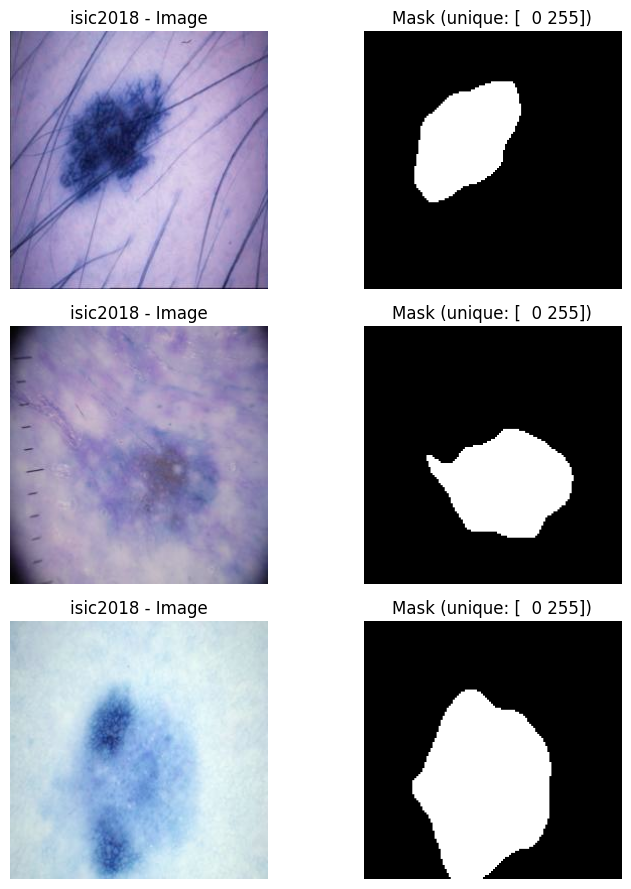


ISIC2017


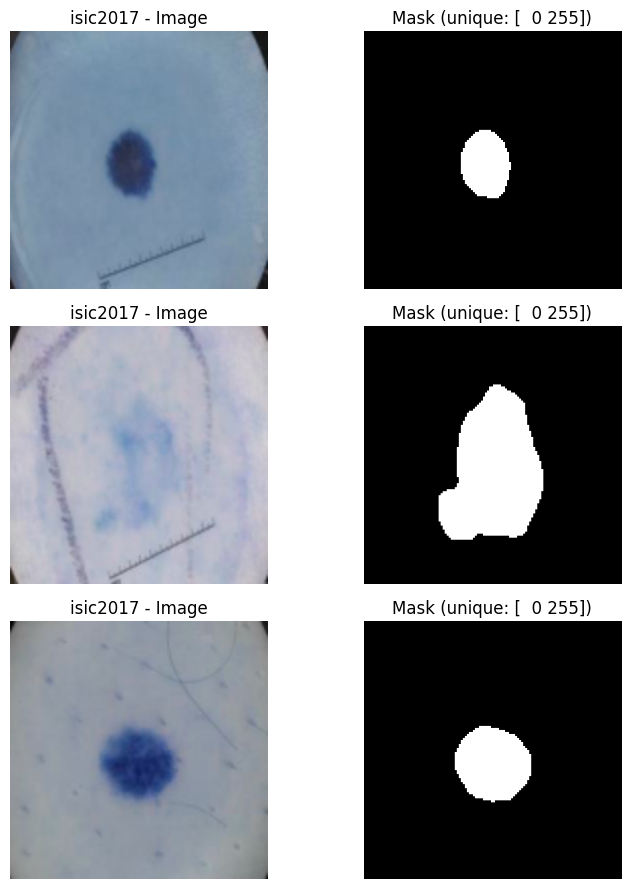


PH2


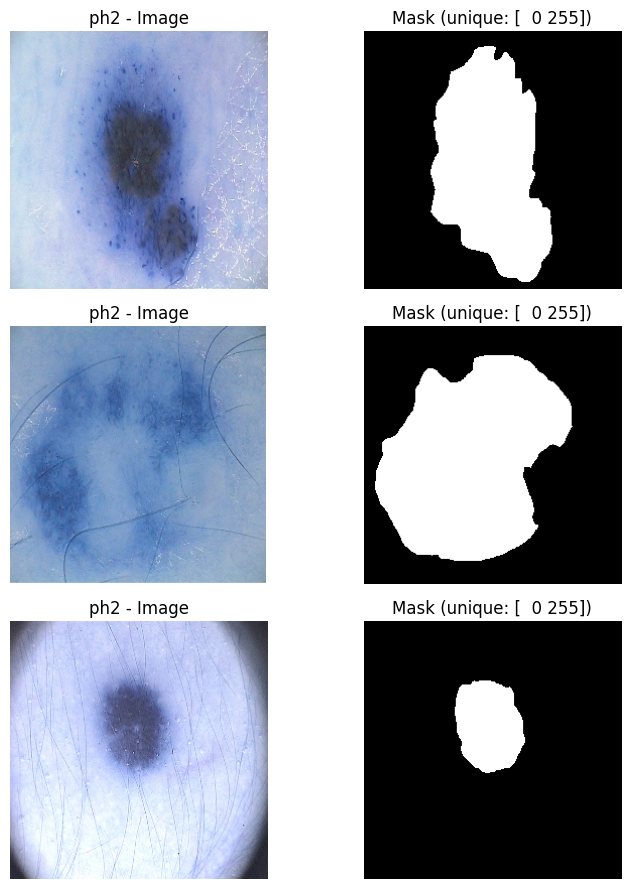


CLINICDB


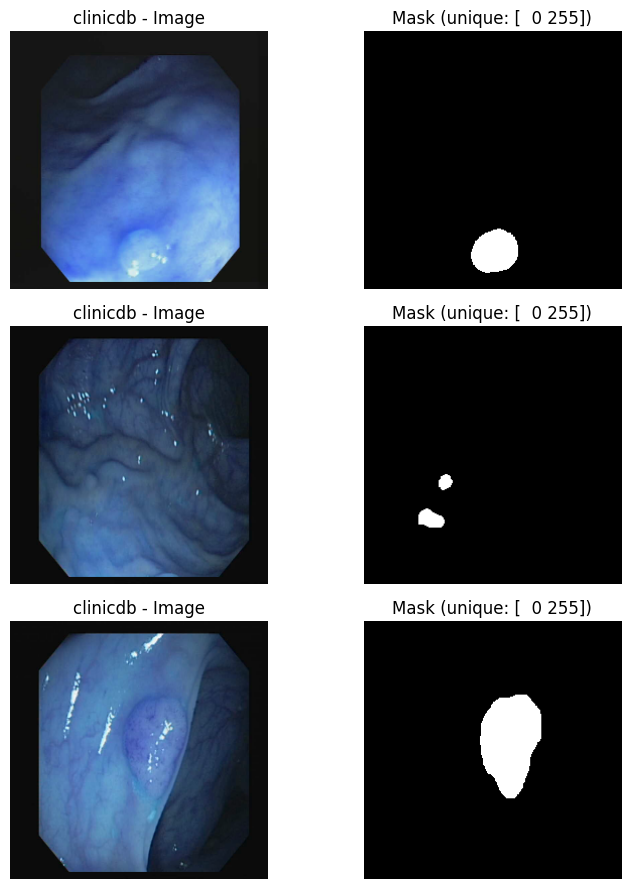


SYNAPSE


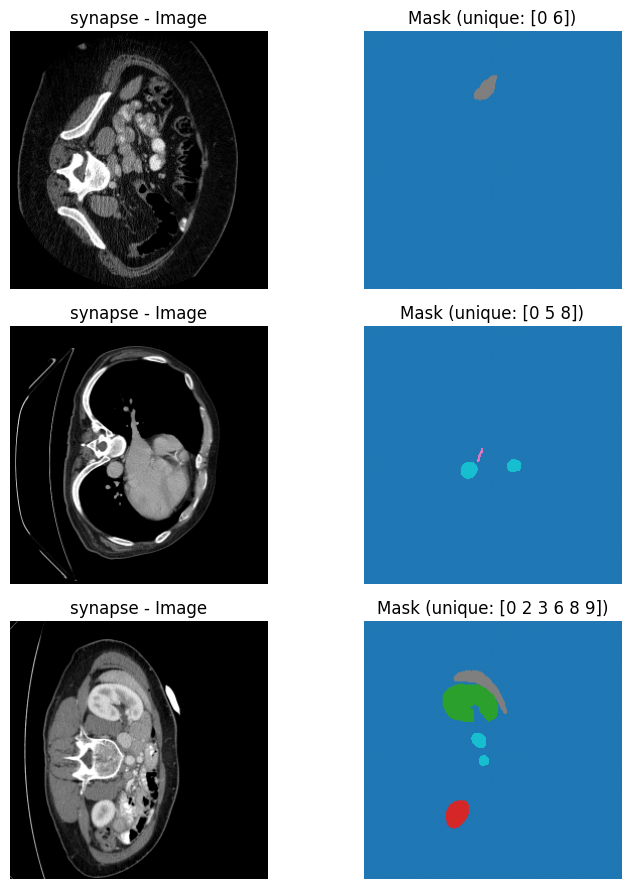

In [5]:
# ============================================================
# DISPLAY RANDOM SAMPLES FROM PROCESSED DATASETS
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

PROCESSED_ROOT = Path('/kaggle/working/processed_datasets')

def show_samples(dataset_name, binary=True, num_samples=3):
    """Display random image-mask pairs from the training set."""
    dataset_path = PROCESSED_ROOT / dataset_name / 'train'
    if not dataset_path.exists():
        print(f"❌ {dataset_name}: training directory not found")
        return

    img_dir = dataset_path / 'images'
    msk_dir = dataset_path / 'masks'
    if not (img_dir.is_dir() and msk_dir.is_dir()):
        print(f"❌ {dataset_name}: missing images/ or masks/")
        return

    # Get all image files
    imgs = list(img_dir.glob('*.png'))
    if not imgs:
        print(f"❌ {dataset_name}: no images found")
        return

    # Randomly select samples
    samples = random.sample(imgs, min(num_samples, len(imgs)))

    # Create figure
    fig, axes = plt.subplots(len(samples), 2, figsize=(8, 3*len(samples)))
    if len(samples) == 1:
        axes = axes.reshape(1, 2)

    for i, img_path in enumerate(samples):
        # Load image (3-channel)
        img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Load corresponding mask
        mask_path = msk_dir / img_path.name
        mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)

        # Display image
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"{dataset_name} - Image")
        axes[i, 0].axis('off')

        # Display mask
        # For binary masks (0/255), we can show as gray with 255 as white.
        # For multi-class, we can use a colormap.
        if binary:
            axes[i, 1].imshow(mask, cmap='gray', vmin=0, vmax=255)
        else:
            axes[i, 1].imshow(mask, cmap='tab10', vmin=0, vmax=8)
        axes[i, 1].set_title(f"Mask (unique: {np.unique(mask)})")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Show samples from each dataset
datasets = {
    'isic2018': {'binary': True},
    'isic2017': {'binary': True},
    'ph2':      {'binary': True},
    'clinicdb': {'binary': True},
    'synapse':  {'binary': False},
}

for name, spec in datasets.items():
    print(f"\n{name.upper()}")
    show_samples(name, binary=spec['binary'], num_samples=3)